# Week 8 Capstone Project  
## Customer Churn Prediction & Retention Strategy Analysis

**Objective:**  
Perform an end-to-end business data analysis to identify why customers churn  
and provide actionable retention recommendations.

**Dataset:** customer_churn.csv  
**Tools:** Python,Pandas,Seaborn,Matplotlib,Scikit-learn,SciPy


## 1.Business Problem

Customer churn is a major challenge for subscription based businesses.  
Losing customers directly impacts revenue and growth.

### Key Question:
**Why are customers leaving and how can churn be reduced?**

### Project Goals:
- Identify patterns among churned customers
- Find important factors affecting churn
- Provide data driven retention strategies


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
sns.set(style="whitegrid")

## 2.Load Dataset


In [6]:
df = pd.read_csv("raw_data.csv")
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [7]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


(500, 9)

## 3.Data Cleaning & Preparation

Steps performed:
- Remove duplicates
- Handle missing values
- Convert data types where required

In [8]:
df = df.drop_duplicates()
df.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [23]:
df.to_csv("data/cleaned_data.csv",index=False)
print("Cleaned dataset saved to data/cleaned_data.csv")


Cleaned dataset saved to data/cleaned_data.csv


## 4.Churn Distribution

This shows how many customers stayed vs churned.

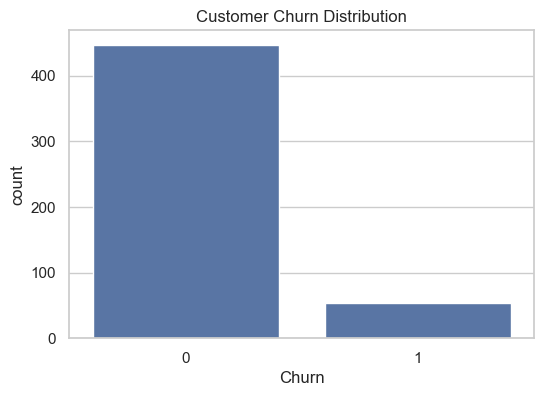

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn Distribution")
plt.show()

## 5.Tenure vs Churn

This helps understand whether newer customers churn more often.

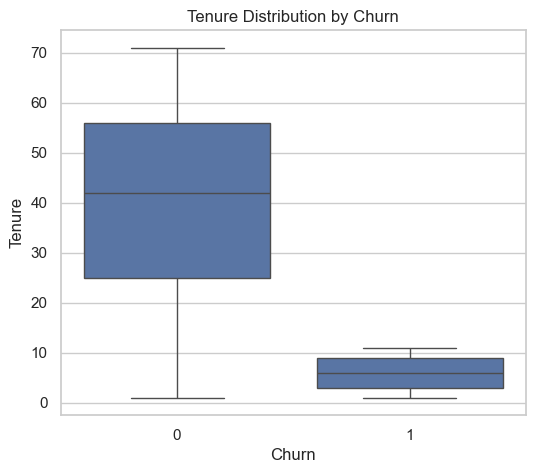

In [11]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Churn",y="Tenure",data=df)
plt.title("Tenure Distribution by Churn")
plt.show()

## 6.Monthly Charges vs Churn

Higher monthly charges may increase churn probability.

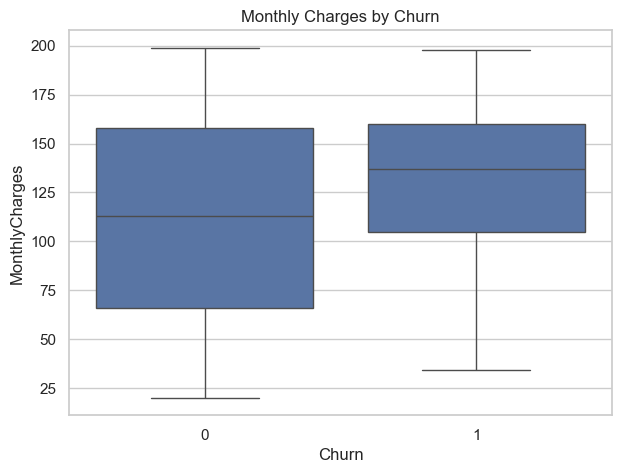

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("Monthly Charges by Churn")
plt.show()

## 7.Contract Type vs Churn

Contract duration often affects customer retention.

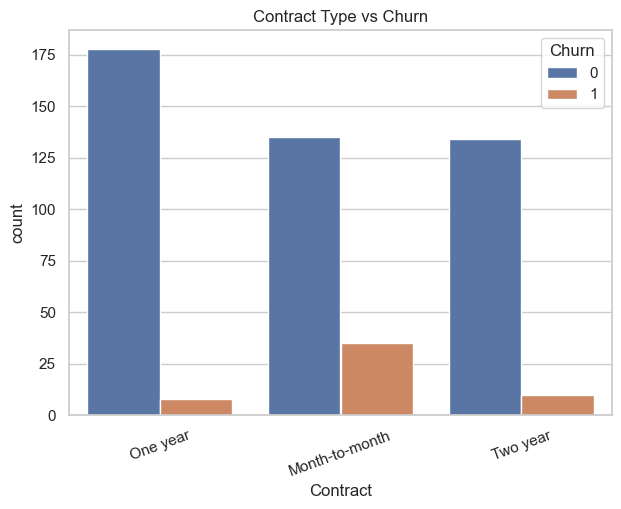

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

## 8.Correlation Heatmap

Shows relationships between numerical variables.

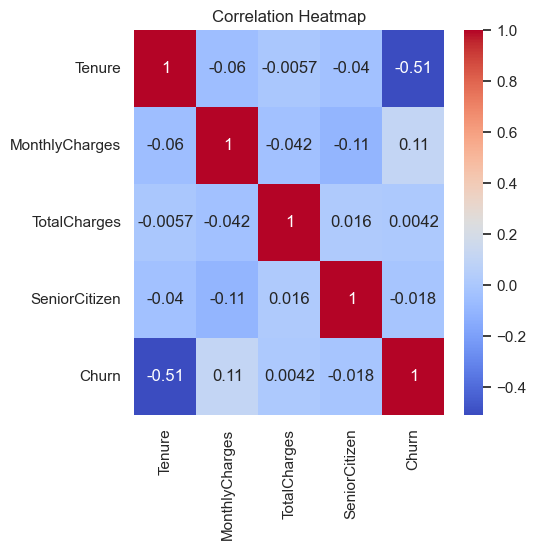

In [15]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 9.Hypothesis Testing

Test whether churned and non-churned customers have different monthly charges.

In [16]:
churn_yes = df[df["Churn"] == 1]["MonthlyCharges"]
churn_no = df[df["Churn"] == 0]["MonthlyCharges"]

t_stat,p_val = stats.ttest_ind(churn_yes,churn_no)
print("T-statistic: ",t_stat)
print("P-value: ",p_val)


T-statistic:  2.4102471700825414
P-value:  0.016303157985223953


If p-value < 0.05 → statistically significant difference in monthly charges.

## 10.Logistic Regression Model

We build a simple predictive model to classify whether a customer will churn.


In [17]:
features = ["Tenure","MonthlyCharges","TotalCharges"]
X = df[features]
y = df["Churn"]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("\nConfusion Matrix : \n",confusion_matrix(y_test,y_pred))
print("\nClassification Report : \n",classification_report(y_test,y_pred))

Accuracy :  0.94

Confusion Matrix : 
 [[80  4]
 [ 2 14]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        84
           1       0.78      0.88      0.82        16

    accuracy                           0.94       100
   macro avg       0.88      0.91      0.89       100
weighted avg       0.94      0.94      0.94       100



## 11.Key Insights

- Customers with higher monthly charges show higher churn tendency.
- Customers with shorter tenure are more likely to leave.
- Contract type strongly influences churn behavior.
- Logistic regression provides measurable churn prediction capability.

## 12.Business Recommendations

1. Provide discounts for high charge customers.  
2. Encourage long term contracts instead of month to month plans.  
3. Focus retention campaigns on new customers within first 6 months.  
4. Use churn prediction model for proactive customer retention.


## 13.Conclusion

This capstone project demonstrates a complete end-to-end business analysis workflow:
data cleaning → EDA → statistical testing → predictive modeling → business strategy.

The analysis provides practical,data-driven recommendations to reduce customer churn
and improve long term revenue.
